In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

# Global parameters
N = 1000  # Number of data points
d = 2     # Dimensionality of input and latent space

In [2]:
# 1a. Generate the dataset X_true
mu_data = np.array([3.0, 2.0])
Sigma_data = np.array([[1.0, 0.0], [0.0, 1.0]])

X_true = np.random.multivariate_normal(mu_data, Sigma_data, N)

print(f"Shape of X_true: {X_true.shape}")

Shape of X_true: (1000, 2)


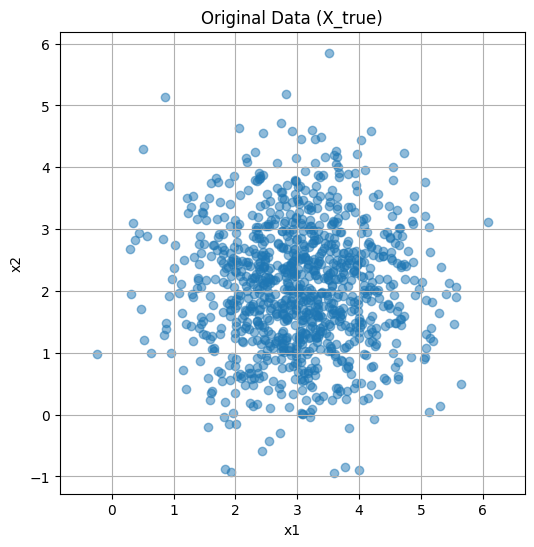

In [3]:
# 1b. Visualize the generated data
plt.figure(figsize=(6, 6))
plt.scatter(X_true[:, 0], X_true[:, 1], alpha=0.5)
plt.title('Original Data (X_true)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.axis('equal')
plt.show()

In [4]:
# Scenario 1: Standard Encoder Parameters
W_mu = np.array([[0.5, 0.0], [0.0, 0.5]])
b_mu = np.array([-0.5, -0.25])
W_ls = np.array([[0.1, 0.0], [0.0, 0.1]])
b_ls = np.array([-1.0, -1.0])

# Decoder Parameters (same for both scenarios)
W_dec = np.array([[1.4, 0.0], [0.0, 1.4]])
b_dec = np.array([1.5, 1.0])

In [5]:
# 3a. Encoding
# The formula is mu = W @ x + b. For a batch X_true (N, 2), we use X @ W.T + b
mu = X_true @ W_mu.T + b_mu
log_sigma_sq = X_true @ W_ls.T + b_ls

print(f"Shape of mu: {mu.shape}")
print(f"Shape of log_sigma_sq: {log_sigma_sq.shape}")

Shape of mu: (1000, 2)
Shape of log_sigma_sq: (1000, 2)


In [6]:
# 3b. Reparameterization Trick
# i. Calculate sigma
sigma = np.exp(0.5 * log_sigma_sq)

# ii. Sample epsilon from a standard normal distribution
epsilon = np.random.randn(N, d)

# iii. Compute latent vectors Z
Z = mu + sigma * epsilon

print(f"Shape of Z: {Z.shape}")

Shape of Z: (1000, 2)


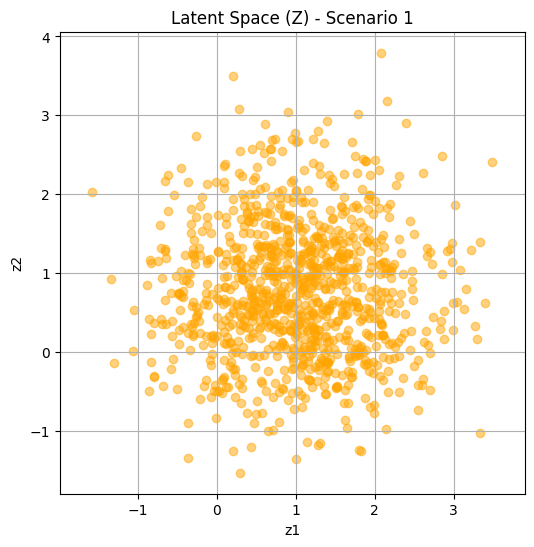

In [7]:
# Optional Visualization of Latent Space Z
plt.figure(figsize=(6, 6))
plt.scatter(Z[:, 0], Z[:, 1], alpha=0.5, c='orange')
plt.title('Latent Space (Z) - Scenario 1')
plt.xlabel('z1')
plt.ylabel('z2')
plt.grid(True)
plt.axis('equal')
plt.show()

In [8]:
# 3c. Decoding
X_prime = Z @ W_dec.T + b_dec

print(f"Shape of X_prime: {X_prime.shape}")

Shape of X_prime: (1000, 2)


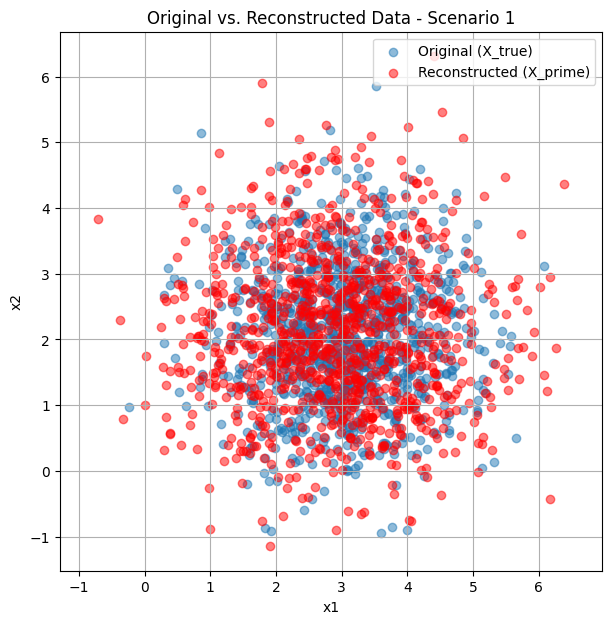

In [9]:
# Optional Visualization of Reconstructed Data
plt.figure(figsize=(7, 7))
plt.scatter(X_true[:, 0], X_true[:, 1], alpha=0.5, label='Original (X_true)')
plt.scatter(X_prime[:, 0], X_prime[:, 1], alpha=0.5, label='Reconstructed (X_prime)', c='red')
plt.title('Original vs. Reconstructed Data - Scenario 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [10]:
# 3d. Loss Calculation
# i. Reconstruction Loss (MSE)
recon_loss_per_sample = np.sum((X_true - X_prime)**2, axis=1)
L_recon = np.mean(recon_loss_per_sample)

# ii. KL Divergence
sigma_sq = np.exp(log_sigma_sq)
kl_div_per_sample = 0.5 * np.sum(sigma_sq + mu**2 - log_sigma_sq - 1, axis=1)

# iii. Average KL Divergence
L_KL = np.mean(kl_div_per_sample)

# iv. Total VAE Loss
Loss = L_recon + L_KL

In [11]:
# 3e. Report values
print("Scenario 1 Results:")
print(f"L_recon: {L_recon:.4f}")
print(f"L_KL:    {L_KL:.4f}")
print(f"Loss:    {Loss:.4f}")

Scenario 1 Results:
L_recon: 2.1049
L_KL:    1.2867
Loss:    3.3916


In [12]:
# 4. New Encoder Parameters ('Collapse')
W_mu_c = np.array([[0.01, 0.01], [-0.01, -0.01]])
b_mu_c = np.array([0.05, -0.05])
W_ls_c = np.array([[0.0, 0.0], [0.0, 0.0]])
b_ls_c = np.array([-0.1, -0.1])

In [13]:
# 4a. Repeat forward pass and loss calculation for Scenario 2

# Encoding with 'collapse' parameters
mu_c = X_true @ W_mu_c.T + b_mu_c
log_sigma_sq_c = X_true @ W_ls_c.T + b_ls_c

# Reparameterization
sigma_c = np.exp(0.5 * log_sigma_sq_c)
# Use the same epsilon for a fair comparison
Z_c = mu_c + sigma_c * epsilon

# Decoding (uses original decoder)
X_prime_c = Z_c @ W_dec.T + b_dec

# Loss Calculation
# Reconstruction Loss
L_recon_c = np.mean(np.sum((X_true - X_prime_c)**2, axis=1))

# KL Divergence
sigma_sq_c = np.exp(log_sigma_sq_c)
L_KL_c = np.mean(0.5 * np.sum(sigma_sq_c + mu_c**2 - log_sigma_sq_c - 1, axis=1))

# Total VAE Loss
Loss_c = L_recon_c + L_KL_c

In [14]:
# 4b. Report new values
print("Scenario 2 (Collapse) Results:")
print(f"L_recon_c: {L_recon_c:.4f}")
print(f"L_KL_c:    {L_KL_c:.4f}")
print(f"Loss_c:    {Loss_c:.4f}")

Scenario 2 (Collapse) Results:
L_recon_c: 9.0537
L_KL_c:    0.0152
Loss_c:    9.0689


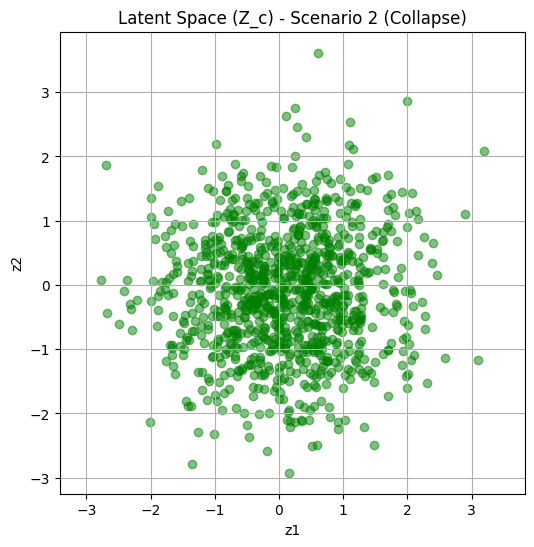

In [15]:
# 4c. Visualize the new latent vectors Z_c
plt.figure(figsize=(6, 6))
plt.scatter(Z_c[:, 0], Z_c[:, 1], alpha=0.5, c='green')
plt.title('Latent Space (Z_c) - Scenario 2 (Collapse)')
plt.xlabel('z1')
plt.ylabel('z2')
plt.grid(True)
plt.axis('equal')
# Compare to prior N(0,I) by setting limits
# plt.xlim(-3, 3)
# plt.ylim(-3, 3)
plt.show()

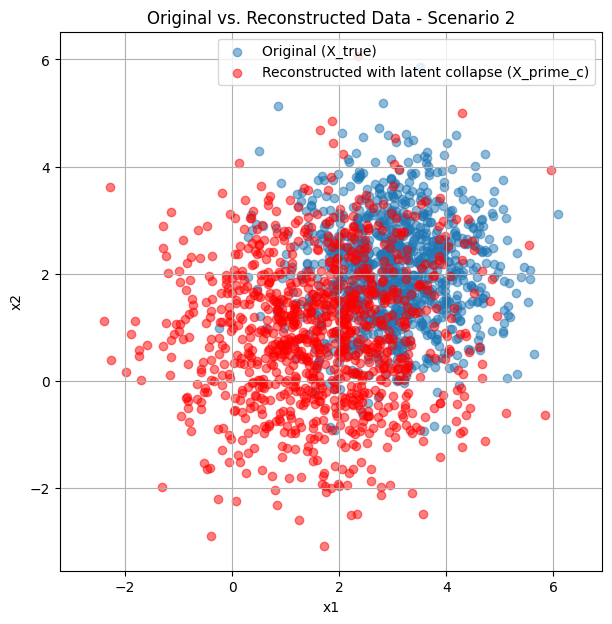

In [16]:
# Optional Visualization of Reconstructed Data
plt.figure(figsize=(7, 7))
plt.scatter(X_true[:, 0], X_true[:, 1], alpha=0.5, label='Original (X_true)')
plt.scatter(X_prime_c[:, 0], X_prime_c[:, 1], alpha=0.5, label='Reconstructed with latent collapse (X_prime_c)', c='red')
plt.title('Original vs. Reconstructed Data - Scenario 2')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

## Analysis of Latent Collapse

### Comparison of Loss Components:

- The reconstruction loss in Scenario 2 (L_recon_c) is significantly higher than in Scenario 1 (L_recon).

- The KL divergence in Scenario 2 (L_KL_c) is dramatically lower than in Scenario 1, and is very close to zero.

### What happened?
The plot of the latent space Z_c shows that all latent vectors are clustered in the region around the origin (0,0) with variance 1. This is because the 'collapse' encoder parameters (W_mu_c, W_ls_c) are very small, effectively ignoring the input x and outputting a mu_c near zero and a log_sigma_sq_c that is a small negative constant. This makes the latent distribution $q(z|x)$ very close to the prior $p(z) = N(0,I)$, which minimizes the KL divergence.

### Why is this undesirable?
This "latent collapse" is a failure mode for VAEs. The encoder fails to learn any useful information from the input data. Since all inputs are mapped to nearly the same point in the latent space, the decoder only ever receives this one signal. Consequently, the decoder can only learn to produce a single, average output, regardless of the input it was supposed to reconstruct. This destroys the model's ability to generate diverse data, which is its primary purpose.